# Neural signal forecasting v4
## Gated axial attention + Temporal conv + GCN

## What changed in v4
- fix input issue: remove adj from input of forward()
- re-organize project structure

In [1]:
# Build dataloader
import torch
import numpy as np
import os
from model_v4 import NFSTNDTModelV4
from utils import *
from trainer import Trainer

input_dir = './'

train_data shape: (560, 20, 89, 9)
test_data shape: (70, 20, 89, 9)
val_data shape: (70, 20, 89, 9)


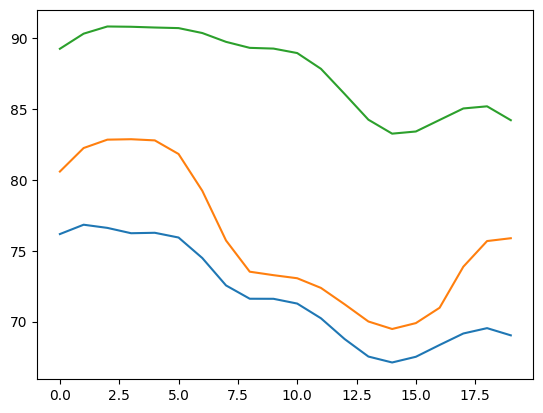

In [2]:
# parameters:
dataset_name = 'beignet'
# dataset_name = 'affi'
if dataset_name == 'beignet':
  num_channels = 89
else:
  num_channels = 239

batch_size = 16
num_epochs = 100
learning_rate = 1e-4
hidden_size = 256
n_heads=4
n_layers=3
dropout=0.1
input_size = num_channels

# define dataloader
train_data, test_data, val_data = load_dataset(
    f'dataset/train_data_{dataset_name}.npz', input_dir)  # B * T * C * F

# print the shape of the train, test, val data
print(f'train_data shape: {train_data.shape}')
print(f'test_data shape: {test_data.shape}')
print(f'val_data shape: {val_data.shape}')

# plot test_data curve for a few channels
import matplotlib.pyplot as plt
plt.plot(test_data[0, :, 0, 1])
plt.plot(test_data[0, :, 1, 1])
plt.plot(test_data[0, :, 2, 1])
plt.show()

In [3]:
from torch.utils.data import DataLoader
import numpy as np
import torch

# --- Dataset / Dataloader ---
train_ds = NeuroForcastDataset(train_data, use_graph=False)
np.savez(f'train_data_average_std_{dataset_name}.npz', average=train_ds.average, std=train_ds.std)

test_ds = NeuroForcastDataset(test_data, use_graph=False, average=train_ds.average, std=train_ds.std)
val_ds  = NeuroForcastDataset(val_data,  use_graph=False, average=train_ds.average, std=train_ds.std)

train_data_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_data_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)
val_data_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

adj_matrix = compute_adj_matrix(train_data, threshold=0.1).to(torch.device('cuda'))

# --- Model ---
model = NFSTNDTModelV4(
    hidden_size=hidden_size,
    input_size=input_size,
    n_heads=n_heads,
    n_layers=n_layers,
    dropout=dropout,
    adj=adj_matrix
).to(torch.device('cuda'))

# --- Loss / Optim / Scheduler ---
loss_fn = torch.nn.MSELoss(reduction="mean")
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)
lambda1 = lambda epoch: 0.95 ** (epoch // 20)   # stable decay
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda1)

# --- Trainer ---
save_path = f'./model_{dataset_name}_v4.pth'  # BEST will be saved here
trainer = Trainer(
    model=model,
    train_data_loader=train_data_loader,
    test_data_loader=test_data_loader,
    val_data_loader=val_data_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=torch.device('cuda'),
    scheduler=scheduler,
    forecasting_mode='multi_step',
    init_steps=10,
    save_path=save_path,
    ckpt_path=None,
    max_grad_norm=1.0,
    validate_every=1,   # every epoch
    save_best=True
)

trainer.train(num_epochs)
print("Best val:", trainer.best_val)
print("Best weight path:", save_path)


Epoch 2/100:   0%|          | 0/35 [00:00<?, ?it/s, train_loss=0.147991, lr=3.00e-04]

Epoch 000 | lr=3.000000e-04 | Train=0.789299 | Val=0.155572
[BEST] Saved to ./model_beignet_v4.pth | best_val=0.155572


Epoch 3/100:   0%|          | 0/35 [00:00<?, ?it/s, train_loss=0.024862, lr=3.00e-04]

Epoch 001 | lr=3.000000e-04 | Train=0.078846 | Val=0.022787
[BEST] Saved to ./model_beignet_v4.pth | best_val=0.022787


Epoch 4/100:   6%|▌         | 2/35 [00:00<00:03, 10.41it/s, train_loss=0.052329, lr=3.00e-04]

...

Epoch 097 | lr=2.443519e-04 | Train=0.014917 | Val=0.020310


Epoch 100/100:   6%|▌         | 2/35 [00:00<00:03, 10.36it/s, train_loss=0.026812, lr=2.44e-04]

Epoch 098 | lr=2.443519e-04 | Train=0.014862 | Val=0.018650


Epoch 100/100: 100%|██████████| 35/35 [00:03<00:00, 10.34it/s, train_loss=0.014527, lr=2.44e-04]
                                                                     

Epoch 099 | lr=2.321343e-04 | Train=0.014527 | Val=0.019698
Best val: 0.017051742225885392
Best weight path: ./model_beignet_v4.pth


[Competition-style] Future10 MSE (model, normalized): 0.015952
[Competition-style] Future10 MSE (model, raw units): 59879.206460
[Naive repeat ]    Future10 MSE (normalized): 0.024642
[Naive repeat ]    Future10 MSE (raw units): 86172.118203


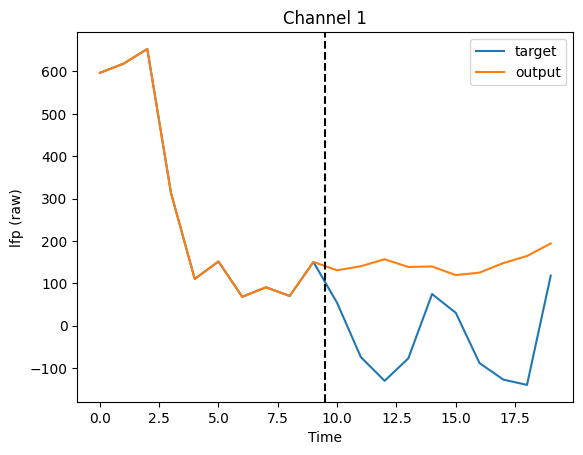

In [4]:
import numpy as np
import torch
import matplotlib.pyplot as plt

INIT_STEPS = 10
DEVICE = torch.device("cuda")

# --- Load BEST model ---
model_test = NFSTNDTModelV4(hidden_size=hidden_size, input_size=input_size, n_heads=n_heads, n_layers=n_layers, dropout=dropout).to(DEVICE)
model_test.load_state_dict(torch.load(f'./model_{dataset_name}_v4.pth', map_location="cpu"))
model_test.eval()

# --- De-normalization helpers (feature 0 only) ---
stats = np.load(f'train_data_average_std_{dataset_name}.npz')
avg_cf = stats['average']  # (1, C*F)
std_cf = stats['std']
num_feats = avg_cf.shape[1] // num_channels
avg_f0 = avg_cf.reshape(1, num_channels, num_feats)[..., 0]
std_f0 = std_cf.reshape(1, num_channels, num_feats)[..., 0]
combine_max = avg_f0 + 4 * std_f0
combine_min = avg_f0 - 4 * std_f0

def denorm_feature0(x, channel_idx=None):
    x_np = x.detach().cpu().numpy() if torch.is_tensor(x) else x
    if x_np.shape[-1] == num_channels:
        return ((x_np + 1) / 2) * (combine_max - combine_min) + combine_min
    if channel_idx is None:
        raise ValueError("channel_idx required for single-channel inputs")
    cmax = combine_max[..., channel_idx]
    cmin = combine_min[..., channel_idx]
    return ((x_np + 1) / 2) * (cmax - cmin) + cmin

def prepare_input_masked(data, init_steps=INIT_STEPS):
    # data: (B,20,C,F)
    future = data.shape[1] - init_steps
    x_in = torch.cat([
        data[:, :init_steps, :, :],
        data[:, init_steps-1:init_steps, :, :].repeat(1, future, 1, 1)
    ], dim=1)
    y_future = data[:, init_steps:, :, 0]  # (B,10,C) feature0 target
    return x_in, y_future

@torch.no_grad()
def eval_future_mse(model, loader, device=DEVICE, init_steps=INIT_STEPS):
    preds, tgts = [], []
    for batch in loader:
        batch = batch.to(device)  # (B,20,C,F)
        x_in, y_future = prepare_input_masked(batch, init_steps=init_steps)

        y_hat_full = model(x_in)  # (B,20,C)

        # enforce competition definition: first 10 steps are the given values
        y_hat_full[:, :init_steps, :] = batch[:, :init_steps, :, 0]

        y_hat_future = y_hat_full[:, init_steps:, :]  # (B,10,C)

        preds.append(y_hat_future.detach().cpu())
        tgts.append(y_future.detach().cpu())

    preds = torch.cat(preds, dim=0)
    tgts  = torch.cat(tgts,  dim=0)
    mse = torch.mean((tgts - preds) ** 2).item()
    return mse, preds.numpy(), tgts.numpy()

@torch.no_grad()
def naive_repeat_baseline_mse(loader, device=DEVICE, init_steps=INIT_STEPS):
    mses = []
    for batch in loader:
        batch = batch.to(device)  # (B,20,C,F)
        y_true = batch[:, init_steps:, :, 0]
        last = batch[:, init_steps-1:init_steps, :, 0].repeat(1, y_true.shape[1], 1)
        mses.append(torch.mean((y_true - last) ** 2).item())
    return float(sum(mses) / max(len(mses), 1))

@torch.no_grad()
def naive_repeat_baseline_mse_raw(loader, device=DEVICE, init_steps=INIT_STEPS):
    mses = []
    for batch in loader:
        batch = batch.to(device)  # (B,20,C,F)
        y_true = batch[:, init_steps:, :, 0]
        last = batch[:, init_steps-1:init_steps, :, 0].repeat(1, y_true.shape[1], 1)
        y_true_raw = denorm_feature0(y_true)
        last_raw = denorm_feature0(last)
        mses.append(float(np.mean((y_true_raw - last_raw) ** 2)))
    return float(sum(mses) / max(len(mses), 1))

mse_model_norm, pred_future_norm, tgt_future_norm = eval_future_mse(model_test, test_data_loader, DEVICE, INIT_STEPS)
mse_naive_norm = naive_repeat_baseline_mse(test_data_loader, DEVICE, INIT_STEPS)
mse_naive_raw = naive_repeat_baseline_mse_raw(test_data_loader, DEVICE, INIT_STEPS)

# inverse back to original units (feature 0)
pred_future = denorm_feature0(pred_future_norm)
tgt_future = denorm_feature0(tgt_future_norm)
mse_model_raw = float(np.mean((tgt_future - pred_future) ** 2))

print(f"[Competition-style] Future10 MSE (model, normalized): {mse_model_norm:.6f}")
print(f"[Competition-style] Future10 MSE (model, raw units): {mse_model_raw:.6f}")
print(f"[Naive repeat ]    Future10 MSE (normalized): {mse_naive_norm:.6f}")
print(f"[Naive repeat ]    Future10 MSE (raw units): {mse_naive_raw:.6f}")

# --- Plot one example (full 20 steps) for chosen channel ---

@torch.no_grad()
def plot_channel(model, data_loader, channel_idx=1, device=torch.device("cuda"), init_steps=10, denorm=True):
    model.eval()
    batch = next(iter(data_loader)).to(device)   # (B,20,C,F)

    # build masked input
    future = batch.shape[1] - init_steps
    x_in = torch.cat([
        batch[:, :init_steps, :, :],
        batch[:, init_steps-1:init_steps, :, :].repeat(1, future, 1, 1)
    ], dim=1)

    # model output
    y_hat = model(x_in)  # (B,20,C)

    # enforce competition rule: first 10 steps are given
    y_hat[:, :init_steps, :] = batch[:, :init_steps, :, 0]

    # pick one sample
    y_true = batch[0, :, channel_idx, 0]
    y_pred = y_hat[0, :, channel_idx]

    if denorm:
        y_true = denorm_feature0(y_true, channel_idx=channel_idx)
        y_pred = denorm_feature0(y_pred, channel_idx=channel_idx)
        ylabel = "lfp (raw)"
    else:
        y_true = y_true.detach().cpu().numpy()
        y_pred = y_pred.detach().cpu().numpy()
        ylabel = "lfp (normalized)"

    plt.figure()
    plt.plot(y_true, label="target")
    plt.plot(y_pred, label="output")
    plt.axvline(x=init_steps-0.5, color="black", linestyle="--")
    plt.title(f"Channel {channel_idx}")
    plt.xlabel("Time")
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()


plot_channel(model_test, test_data_loader, channel_idx=1)